In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
import numpy as np
from utils import display_graph, display_matrix, display_path, time_method


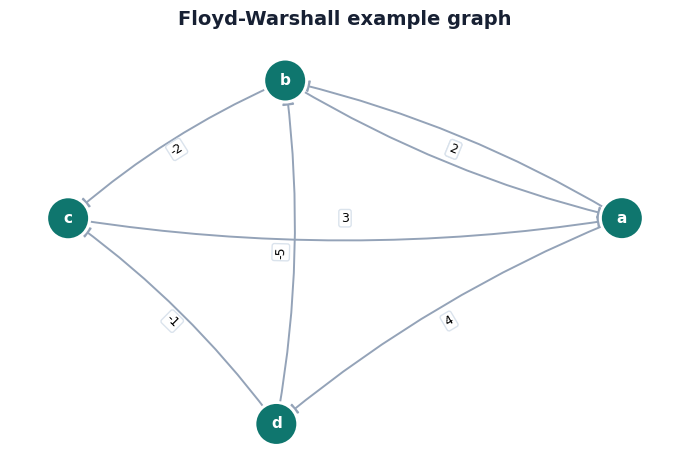

In [3]:
# graph = {
#     0: [(7, 0.16), (2, 0.26), (4, 0.38), (6, 0.58)],
#     1: [(5, 0.32), (7, 0.19), (2, 0.36), (3, 0.29)],
#     2: [(1, 0.36), (3, 0.17), (7, 0.34), (0, 0.26), (6, 0.40)],
#     3: [(1, 0.29), (2, 0.17), (6, 0.52)],
#     4: [(5, 0.35), (7, 0.37), (0, 0.38), (6, 0.93)],
#     5: [(4, 0.35), (7, 0.28), (1, 0.32)],
#     6: [(3, 0.52), (2, 0.40), (0, 0.58), (4, 0.93)],
#     7: [(5, 0.28), (1, 0.19), (4, 0.37), (0, 0.16), (2, 0.34)]
# }

graph = {
    "a": [("b", 1), ("d", 4)],
    "b": [("a", 2), ("c", -2)],
    "c": [("a", 3)],
    "d": [("b", -5), ("c", -1)],
}

display_graph(graph, title="Floyd-Warshall example graph")


In [4]:
def build_adjacency_matrix(adjancency_list: dict):
    node_to_idx = {node: i for i, node in enumerate(adjancency_list)}
    
    idx_to_node = {i: node for i, node in enumerate(adjancency_list)}

    n = len(adjancency_list)

    # Inf matrix with diagonal elements = 0
    matrix = np.full((n, n), np.inf)
    np.fill_diagonal(matrix, 0)

    next_node_matrix = np.full((n,n), None)

    for node, neighbors in adjancency_list.items():
        row_idx = node_to_idx[node]

        for neighbor, distance in neighbors:
            col_idx = node_to_idx[neighbor]

            matrix[row_idx, col_idx] = distance
            next_node_matrix[row_idx, col_idx] = col_idx
    return {
        "node_to_idx": node_to_idx,
        "idx_to_node": idx_to_node,
        "adjancency_matrix": matrix,
        "next_node_matrix": next_node_matrix
    }


In [5]:
built = build_adjacency_matrix(graph)
display_matrix(
    built["adjancency_matrix"],
    row_labels=built["idx_to_node"],
    col_labels=built["idx_to_node"],
    title="L^(0)",
    caption="Initial adjacency matrix",
)


,a,b,c,d
a,0,1,∞,4
b,2,0,-2,∞
c,3,∞,0,∞
d,∞,-5,-1,0


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h

In [6]:
built = build_adjacency_matrix(graph)
display_matrix(
    built["next_node_matrix"],
    row_labels=built["idx_to_node"],
    col_labels=built["idx_to_node"],
    title="Next-node matrix",
    caption="Entries store the next node index used to reconstruct each path",
)


,a,b,c,d
a,-,1,-,3
b,0,-,2,-
c,0,-,-,-
d,-,1,2,-


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h

In [7]:
def ford_warshall(graph, source, dest):
    
    if any(node not in graph for node in (source, dest)):
        raise ValueError("Source or Target node not in the graph")
    
    # get adjancency matrix of graph
    built = build_adjacency_matrix(graph)

    path = built["adjancency_matrix"]
    idx_to_node = built["idx_to_node"]
    node_to_idx = built["node_to_idx"]
    next_node_matrix = built["next_node_matrix"]
    for node_k in graph:
        for node_i in graph:
            for node_j in graph:
                i = node_to_idx[node_i]
                j = node_to_idx[node_j]
                k = node_to_idx[node_k]

                current_d_i_j = path[i, j]
                d_i_j_with_k = path[i, k] + path[k,j]

                # # Update path
                # path[i, j] = min(current_d_i_j, d_i_j_with_k)\
                if d_i_j_with_k < current_d_i_j:
                    path[i, j] = min(current_d_i_j, d_i_j_with_k)
                    next_node_matrix[i, j] = next_node_matrix[i, k]

    if np.any(np.diag(path) < 0):
        raise ValueError("There is a negative cycle in this graph. Stop here!")

    # Get shortest path from source to destination
    start = node_to_idx[source] 
    im = node_to_idx[source] 
    shortest_path = []
    dest = node_to_idx[dest]
    while im != dest:
        shortest_path.append(idx_to_node[im])
        im = next_node_matrix[im][dest]
    shortest_path.append(idx_to_node[dest])
    cost = path[start, dest]
    display_path(shortest_path, title=f"Shortest path {source} -> {idx_to_node[dest]}", cost=cost)
    return path, next_node_matrix, shortest_path


In [8]:
(path, next_node_matrix, shortest_path), floyd_warshall_time = time_method("Floyd-Warshall", ford_warshall, graph, "b", "d")

Floyd-Warshall time: 0.001557 seconds


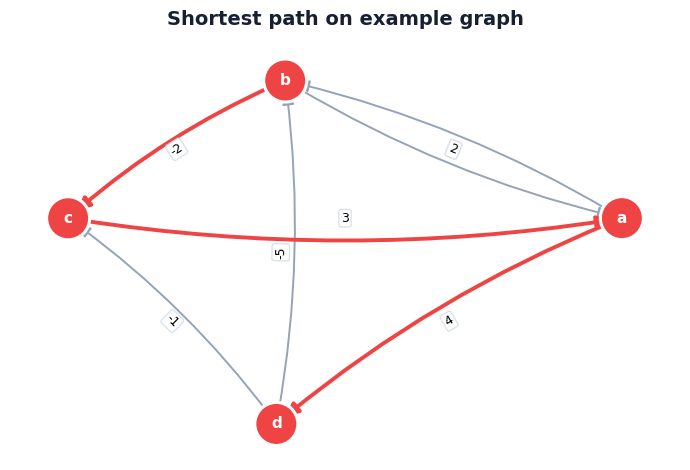

In [9]:
display_graph(graph, title="Shortest path on example graph", path=shortest_path)


## Assigment 1

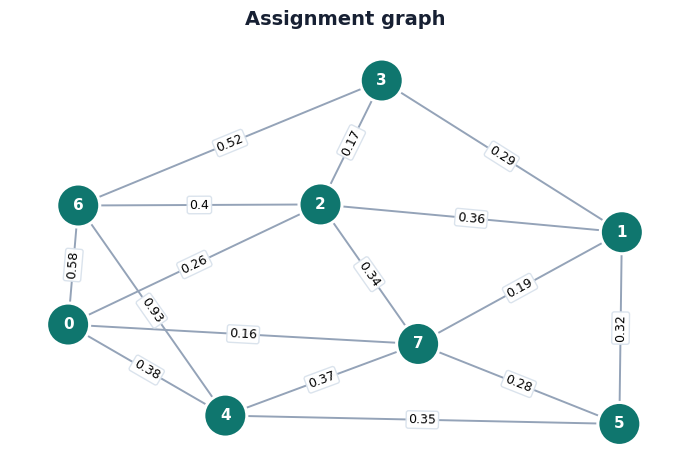

In [10]:
graph = {
    0: [(7, 0.16), (2, 0.26), (4, 0.38), (6, 0.58)],
    1: [(5, 0.32), (7, 0.19), (2, 0.36), (3, 0.29)],
    2: [(1, 0.36), (3, 0.17), (7, 0.34), (0, 0.26), (6, 0.40)],
    3: [(1, 0.29), (2, 0.17), (6, 0.52)],
    4: [(5, 0.35), (7, 0.37), (0, 0.38), (6, 0.93)],
    5: [(4, 0.35), (7, 0.28), (1, 0.32)],
    6: [(3, 0.52), (2, 0.40), (0, 0.58), (4, 0.93)],
    7: [(5, 0.28), (1, 0.19), (4, 0.37), (0, 0.16), (2, 0.34)]
}

display_graph(graph, title="Assignment graph")


In [11]:
built = build_adjacency_matrix(graph)
display_matrix(
    built["adjancency_matrix"],
    row_labels=built["idx_to_node"],
    col_labels=built["idx_to_node"],
    title="Assignment adjacency matrix",
)


,0,1,2,3,4,5,6,7
0,0,∞,0.26,∞,0.38,∞,0.58,0.16
1,∞,0,0.36,0.29,∞,0.32,∞,0.19
2,0.26,0.36,0,0.17,∞,∞,0.4,0.34
3,∞,0.29,0.17,0,∞,∞,0.52,∞
4,0.38,∞,∞,∞,0,0.35,0.93,0.37
5,∞,0.32,∞,∞,0.35,0,∞,0.28
6,0.58,∞,0.4,0.52,0.93,∞,0,∞
7,0.16,0.19,0.34,∞,0.37,0.28,∞,0


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h

In [12]:
for i in range (0, 7 + 1):
    path, next_node_matrix, shortest_path = ford_warshall(graph, 0, i)

built = build_adjacency_matrix(graph)
display_matrix(
    next_node_matrix,
    row_labels=built["idx_to_node"],
    col_labels=built["idx_to_node"],
    title="Next-node matrix to trace paths",
)
display_matrix(
    path,
    row_labels=built["idx_to_node"],
    col_labels=built["idx_to_node"],
    title="All-pairs shortest-path matrix L",
)


,0,1,2,3,4,5,6,7
0,-,7,2,2,4,7,6,7
1,7,-,2,3,7,5,2,7
2,0,1,-,3,0,7,6,7
3,2,1,2,-,2,1,6,1
4,0,7,0,0,-,5,6,7
5,7,1,7,1,4,-,7,7
6,0,2,2,3,4,0,-,0
7,0,1,2,1,4,5,0,-


,0,1,2,3,4,5,6,7
0,0,0.35,0.26,0.43,0.38,0.44,0.58,0.16
1,0.35,0,0.36,0.29,0.56,0.32,0.76,0.19
2,0.26,0.36,0,0.17,0.64,0.62,0.4,0.34
3,0.43,0.29,0.17,0,0.81,0.61,0.52,0.48
4,0.38,0.56,0.64,0.81,0,0.35,0.93,0.37
5,0.44,0.32,0.62,0.61,0.35,0,1.02,0.28
6,0.58,0.76,0.4,0.52,0.93,1.02,0,0.74
7,0.16,0.19,0.34,0.48,0.37,0.28,0.74,0


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h